# TubAR: Quantifying Tuber Shape and Skin Traits from Images — R reproduction in Colab

**Paper:** M. Miller, C. S. Carley, L. M. Shannon, *"TubAR: an R Package for Quantifying Tuber Shape and Skin Traits
from Images"*, American Journal of Potato Research **100**(1):52–62, DOI
[10.1007/s12230-022-09894-z](https://doi.org/10.1007/s12230-022-09894-z).

**What this notebook does (partial demonstration):** it runs the **authors' own R package
[TubAR](https://github.com/shannonlabumn/TubAR) (Tuber Analysis in R), pinned at commit `79d28fc7c399` (v1.1.0)**, on
**two of the package's own vignette example photos** (`FY3Ch1_15_15.jpg`, `2020fy2_092.jpg` — light-box images of tuber clones with a
CameraTrax 24-color card). It reproduces the package's core workflow exactly as designed for a batch of photos:
`shape.all()` (bounding-box width/length, perimeters, areas, compactness, roundness, maximum length), `skin.all(...)`
(skinning %, redness, lightness with 24-color-card correction), and the tagged-data CSV exports `shape.export()` /
`skin.export()`. Computed traits are compared against the **authors' own reference outputs**
`inst/example_data/shape_exmp.rds` / `skin_exmp.rds` generated with the same functions. Two photos are used because
TubAR's export functions are batch-oriented over a working directory (the authors' vignette used all ten `inst/images`
photos).

**Execution status:** executed partial demonstration — the scientific computation is the **authors' own R code, used
verbatim**; no method step is re-implemented. **Python is only the launcher** (this notebook writes readable R scripts
and runs them with `Rscript`). Two documented headless adaptations, both using only author code paths: (1) the
`skin.all(display=TRUE, mode="debug")` on-screen skinning mask is captured into PNG files via an R `png()` device; (2)
the skin reference check is run **twice** — with the vignette call (package default `color.values="revised"`) and with
`color.values="default"` (CameraTrax manufacturer values) — because the authors' reference RDS provably matches the
manufacturer variant (see §7). Not covered: the paper's heritability comparison against visual scales (its
evaluation-population images and visual ratings are not publicly available) and the chip/fry color functions.

**日本語の概要:** このノートブックは、ジャガイモ塊茎の形状・皮膚形質を画像から定量化する R パッケージ
**TubAR（作者自身の実装、固定コミット）** をそのまま実行します。Python は起動装置（ランチャー）のみで、R の
科学計算コードは再実装していません。パッケージのバッチ設計に従い、vignette のサンプル画像 2 枚を使って
`shape.all()`、`skin.all()`、`shape.export()` / `skin.export()` を実行し、作者の参照出力
`shape_exmp.rds` / `skin_exmp.rds` と比較します。デバッグ表示は `png()` デバイスで保存し（ヘッドレス化）、
カラー補正は vignette 既定の `revised` とメーカー値 `default` の両方を比較します。

**Runtime:** **CPU only** — no GPU, deep-learning framework, or model weights are involved (pure-R image analysis).
**実行環境:** CPU のみで動作します（GPU 不要）。**Expected wall time:** ≈ 15 minutes total
(≈ 5 min R-stack install, ≈ 1 min downloads, ≈ 8 min analysis); ≈ 65 MB downloads (apt packages + 6.6 MB data).
**目安の実行時間:** 合計約 15 分、ダウンロード約 65MB。Select *Runtime → Run all* / 「ランタイム → すべてのセルを実行」.

## 1. Install the R stack (prebuilt Ubuntu packages)

TubAR depends on EBImage and Biobase (Bioconductor) plus sp, minpack.lm, Morpho, future, future.apply and boot. Ubuntu
provides prebuilt packages for all of them, which avoids long BiocManager source compiles. This takes a few minutes.
Expected result: `apt exit: 0`.
（TubAR の依存 R パッケージを Ubuntu のビルド済みパッケージで導入します。数分かかります。）

In [ ]:
import subprocess
cmd = ("apt-get update -qq && "
       "apt-get install -y -qq r-base-core r-bioc-ebimage r-bioc-biobase "
       "r-cran-morpho r-cran-minpack.lm r-cran-sp r-cran-future r-cran-future.apply "
       "r-cran-boot > /content/apt.log 2>&1; tail -3 /content/apt.log")
r = subprocess.run(["bash", "-c", cmd])
print("apt exit:", r.returncode)

apt exit: 0


### Verify R and the eight dependencies
Confirms that every package `library(TubAR)` will need is loadable before installing TubAR itself.
（R と依存パッケージが読み込めることを確認します。）

In [ ]:
import subprocess
script = ('cat(R.version.string, "\n"); '
          'for (p in c("EBImage","Biobase","sp","minpack.lm","Morpho","future","future.apply","boot")) '
          'cat(p, as.character(packageVersion(p)), "\n")')
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("R dependency check failed:\n" + r.stderr[-1000:])

R version 4.6.1 (2026-06-24) 
EBImage 4.54.0 
Biobase 2.72.0 
sp 2.2.3 
minpack.lm 1.2.4 
Morpho 2.13 
future 1.76.0 
future.apply 1.20.2 
boot 1.3.32 



## 2. Install TubAR from the pinned author commit

Downloads the author repository archive at commit `79d28fc7c399` **inside this Colab VM** and installs it as a source
package (TubAR is pure R — no compilation). The printed `Version` and `License` come from the package's own
DESCRIPTION: expected **1.1.0**, **CC BY-SA 4.0** (the authors' declared license; the repository has no separate
LICENSE file — attribution is preserved here and in the report).
（固定コミットから TubAR 本体をソースインストールします。バージョンとライセンスを確認します。）

In [ ]:
import subprocess
cmd = f'''
curl -fsSL --retry 3 -o /content/tubar.tar.gz https://github.com/shannonlabumn/TubAR/archive/79d28fc7c399560111adce3deb29f32f8c84910e.tar.gz
Rscript -e 'install.packages("/content/tubar.tar.gz", repos=NULL, type="source"); \
  stopifnot(as.character(packageVersion("TubAR")) == "1.1.0"); \
  cat("TubAR", as.character(packageVersion("TubAR")), "installed; License:", \
      packageDescription("TubAR")$License, "\n")'
'''
r = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
print(r.stdout[-800:])
if r.returncode:
    raise RuntimeError("TubAR install failed:\n" + r.stderr[-800:])

See '?rgl.useNULL' for ways to avoid this warning.
See '?rgl.useNULL' for ways to avoid this warning.
See '?rgl.useNULL' for ways to avoid this warning.
TubAR 1.1.0 installed; License: CC BY-SA 4.0 



## 3. Download the sample data (kept inside Colab)

Fetches, from the pinned commit raw URLs: the two vignette example photos `inst/images/FY3Ch1_15_15.jpg` and
`inst/images/2020fy2_092.jpg` (light-box photos of tuber clones with the 24-color card in the bottom-right corner), plus the
authors' reference outputs `inst/example_data/shape_exmp.rds` and `skin_exmp.rds` (a 112×10 per-tuber trait matrix and
an `skin.all()` result list covering 11 images, used as the vignette's worked example). Validates JPEG magic bytes and
RDS dimensions before use.
（サンプル画像 2 枚と作者の参照出力を固定コミットからダウンロードし、検証します。）

In [ ]:
import hashlib, os, subprocess, urllib.request
files = {
    "FY3Ch1_15_15.jpg":         f"https://raw.githubusercontent.com/shannonlabumn/TubAR/79d28fc7c399560111adce3deb29f32f8c84910e/inst/images/FY3Ch1_15_15.jpg",
    "2020fy2_092.jpg":         f"https://raw.githubusercontent.com/shannonlabumn/TubAR/79d28fc7c399560111adce3deb29f32f8c84910e/inst/images/2020fy2_092.jpg",
    "shape_exmp.rds": f"https://raw.githubusercontent.com/shannonlabumn/TubAR/79d28fc7c399560111adce3deb29f32f8c84910e/inst/example_data/shape_exmp.rds",
    "skin_exmp.rds":  f"https://raw.githubusercontent.com/shannonlabumn/TubAR/79d28fc7c399560111adce3deb29f32f8c84910e/inst/example_data/skin_exmp.rds",
}
os.makedirs("/content/tubar_data", exist_ok=True)
for name, url in files.items():
    dest = "/content/tubar_data/" + name
    urllib.request.urlretrieve(url, dest)
    b = open(dest, "rb").read()
    kind = "JPEG" if b[:3] == b"\xff\xd8\xff" else "RDS/binary"
    print(f"{name}: {len(b)} bytes sha256={hashlib.sha256(b).hexdigest()[:16]}… ({kind})")
script = ('load("/content/tubar_data/shape_exmp.rds"); stopifnot(dim(shape_exmp) == c(112, 10)); '
          'load("/content/tubar_data/skin_exmp.rds"); stopifnot(dim(skin_exmp$median.values) == c(11, 3)); '
          'cat("reference data load OK; shape_exmp", nrow(shape_exmp), "rows; images:", \
              length(unique(shape_exmp[, 1])), "\n")')
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("Reference RDS validation failed:\n" + r.stderr[-1000:])

FY3Ch1_15_15.jpg: 3650026 bytes sha256=70fffe9743246689… (JPEG)
2020fy2_092.jpg: 2927795 bytes sha256=19e07fa5fc8d0e6d… (JPEG)


shape_exmp.rds: 7960 bytes sha256=f8af0dfb96b41ac3… (RDS/binary)
skin_exmp.rds: 1145 bytes sha256=d2b19514e48ef239… (RDS/binary)


reference data load OK; shape_exmp 112 rows; images: 11 



## 4. Input preview

Shows the two actual samples — light-box photos of up to 10 tubers of one clone each with the 24-color card in the
bottom-right corner, per the vignette's imaging protocol (Canon Rebel T6i, 24mm, ISO 100, f/5.6). Dimensions are read
from the downloaded files.
（サンプル画像 2 枚を表示します。ライトボックス撮影、右下にカラーカード。）

input: FY3Ch1_15_15.jpg (5840, 3960) RGB


input: 2020fy2_092.jpg (5880, 3960) RGB


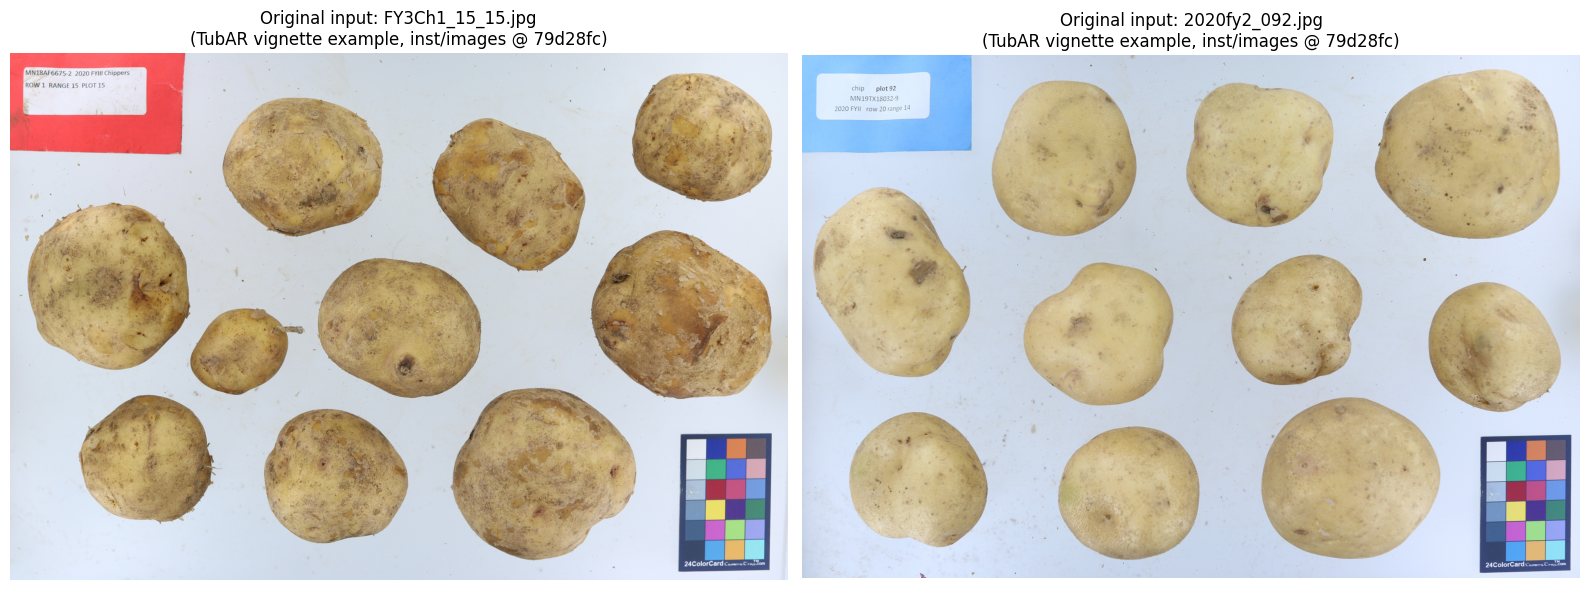

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, name in zip(axes, ["FY3Ch1_15_15.jpg", "2020fy2_092.jpg"]):
    im = Image.open("/content/tubar_data/" + name)
    print("input:", name, im.size, im.mode)
    ax.imshow(im)
    ax.set_title(f"Original input: {name}\n(TubAR vignette example, inst/images @ 79d28fc)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Shape traits — the author's `shape.all()`

`shape.all()` processes every JPEG in the working directory, so both photos are copied into a dedicated directory
first (author-documented batch behavior; the same directory is reused for `shape.export()` later). Runs
`shape.all(n.core=1, pix.min=4e3, scaledown=4, colorcard="bottomright")` — the package defaults, matching the
vignette's settings: images are downscaled 4×, objects smaller than `pix.min` are dropped, and the bottom-right
object (the color card) is removed before per-tuber bounding-box/convex-hull geometry. Expected: well under a minute,
several tuber rows per image.
（作者の shape.all() を 2 枚画像の専用ディレクトリで実行します。）

In [ ]:
import os, shutil, subprocess
os.makedirs("/content/tubar_run/shape", exist_ok=True)
for name in ["FY3Ch1_15_15.jpg", "2020fy2_092.jpg"]:
    shutil.copy("/content/tubar_data/" + name, "/content/tubar_run/shape/")
script = r'''
suppressMessages(library(TubAR))
setwd("/content/tubar_run/shape")
t0 <- Sys.time()
shape_res <- shape.all(n.core=1, pix.min=4e3, scaledown=4, colorcard="bottomright")
cat("elapsed_sec:", round(as.numeric(difftime(Sys.time(), t0, units="secs")), 1), "
")
saveRDS(shape_res, "/content/tubar_run/shape_res.rds")
cat("tuber rows: FY3Ch1_15_15 =", sum(shape_res[, 1] == "FY3Ch1_15_15"),
    " 2020fy2_092 =", sum(shape_res[, 1] == "2020fy2_092"), "
")
cat("columns:", paste(colnames(shape_res), collapse=", "), "
")
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("shape.all failed:\n" + r.stderr[-1500:])

elapsed_sec: 28.3 
tuber rows: FY3Ch1_15_15 = 11  2020fy2_092 = 10 
columns: image, bbox.width, bbox.height, perim, convex.perim, area, chull.area, roundness, compactness, max.length 



## 6. Skin traits — the author's `skin.all()` with the debug mask captured headlessly

In interactive use, `skin.all(display=TRUE, mode="debug")` draws each photo with its skinned-area mask on screen.
**Headless adaptation:** for each photo, a dedicated single-image directory is used and the identical
vignette-call skin run is wrapped in an R `png()` device, saving `skin_debug_<image>.png` (black = background, white
= detected tuber, gray = skinned area, numbers = detected tubers). The values computed here are identical to the
batch run in §7 — `skin.all()` treats each photo independently.
（各画像ごとに単独ディレクトリで skin.all を実行し、デバッグマスクを png 保存します。）

In [ ]:
import os, shutil, subprocess
os.makedirs("/content/tubar_run", exist_ok=True)
script = r'''
suppressMessages(library(TubAR))
for (img in c("FY3Ch1_15_15.jpg", "2020fy2_092.jpg")) {
  d <- file.path("/content/tubar_run/skin_dbg", sub("\\.jpg$", "", img))
  dir.create(d, recursive=TRUE, showWarnings=FALSE)
  file.copy(file.path("/content/tubar_data", img), d, overwrite=TRUE)
  setwd(d)
  png("/content/tubar_run/skin_debug_tmp.png", width=1400, height=1000)
  skin.all(n.core=1, display=TRUE, mode="debug", write.clean=FALSE,
           pix.min=4e3, scaledown=4, colorcard="bottomright")
  dev.off()
  file.rename("/content/tubar_run/skin_debug_tmp.png",
              file.path("/content/tubar_run", paste0("skin_debug_", sub("\\.jpg$", "", img), ".png")))
  cat("saved mask for", img, "
")
}
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("skin debug capture failed:\n" + r.stderr[-1500:])

saved mask for FY3Ch1_15_15.jpg 
saved mask for 2020fy2_092.jpg 



### Input with the TubAR skinning mask

Displays the original input `{IMG1}` next to the `mode="debug"` mask saved by the author's method: gray pixels are
the area TubAR classified as **skinned** (above the fitted CIELAB-b threshold). This overlay is the method's own
measurement output on the real input, not an annotation added by this notebook.
（入力画像と、作者メソッドが分類したスキニング領域マスクを並べて表示します。）

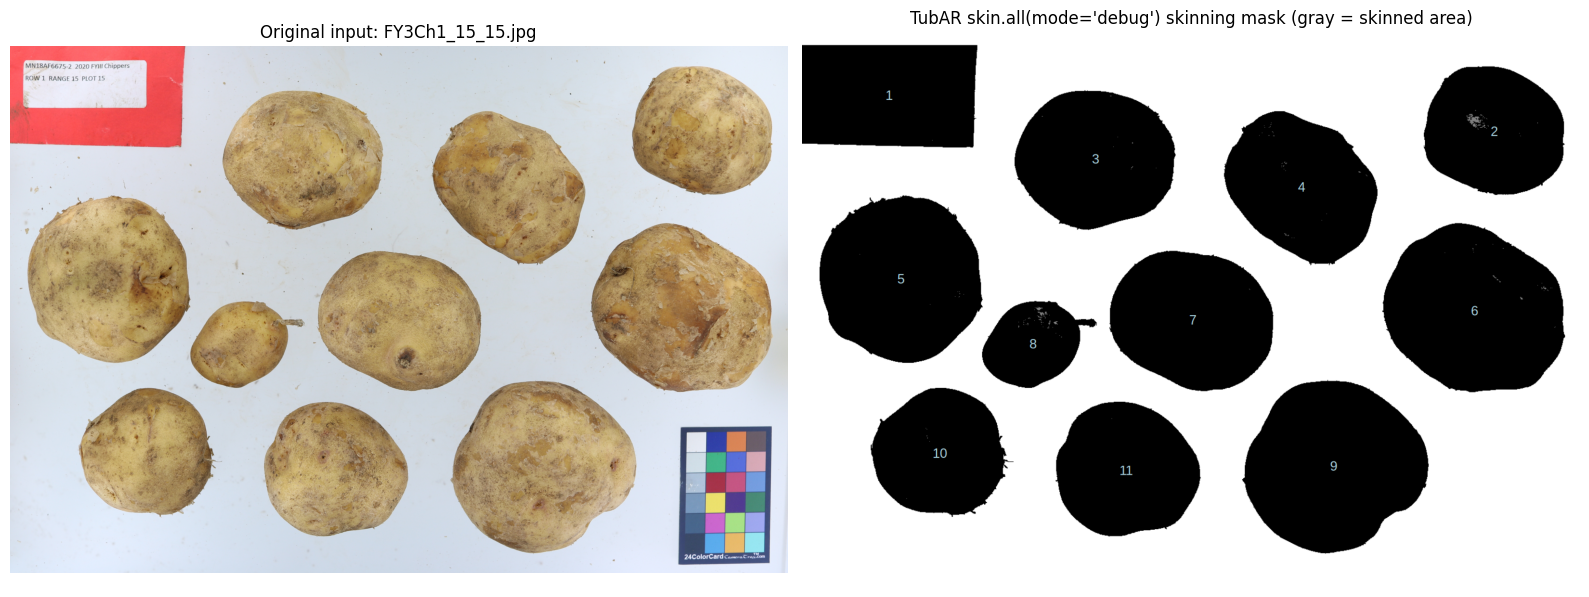

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(Image.open("/content/tubar_data/FY3Ch1_15_15.jpg"))
axes[0].set_title("Original input: FY3Ch1_15_15.jpg")
axes[1].imshow(mpimg.imread("/content/tubar_run/skin_debug_FY3Ch1_15_15.png"))
axes[1].set_title("TubAR skin.all(mode='debug') skinning mask (gray = skinned area)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Batch `skin.all()` — vignette call and manufacturer color reference

Runs the authors' batch function on the two-photo directory twice: (a) the **vignette call** exactly as written
(`color.values` unspecified → the package default `"revised"`), and (b) `color.values="default"` (the CameraTrax
manufacturer RGB values embedded in `R/skin_func.R`). Both use `display=FALSE` (the batch path is needed for the
export functions, and no mask is required here). Expected: a few minutes.
（2 枚構成のバッチ skin.all を、vignette 既定の revised とメーカー値 default の両方で実行します。）

In [ ]:
import os, shutil, subprocess
os.makedirs("/content/tubar_run/skin", exist_ok=True)
for name in ["FY3Ch1_15_15.jpg", "2020fy2_092.jpg"]:
    shutil.copy("/content/tubar_data/" + name, "/content/tubar_run/skin/")
script = r'''
suppressMessages(library(TubAR))
setwd("/content/tubar_run/skin")
t0 <- Sys.time()
skin_res_rev <- skin.all(n.core=1, display=FALSE, mode="debug", write.clean=FALSE,
                         pix.min=4e3, scaledown=4, colorcard="bottomright")
skin_res_def <- skin.all(n.core=1, display=FALSE, mode="debug", write.clean=FALSE,
                         pix.min=4e3, scaledown=4, colorcard="bottomright", color.values="default")
cat("elapsed_sec:", round(as.numeric(difftime(Sys.time(), t0, units="secs")), 1), "
")
saveRDS(skin_res_rev, "/content/tubar_run/skin_res_rev.rds")
saveRDS(skin_res_def, "/content/tubar_run/skin_res_def.rds")
cat("median values per image (vignette call, color.values=revised):\n")
print(skin_res_rev$median.values)
cat("median values per image (color.values=default):\n")
print(skin_res_def$median.values)
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("skin.all batch failed:\n" + r.stderr[-1500:])

elapsed_sec: 533.7 
median values per image (vignette call, color.values=revised):
             %skinned redness lightness
2020fy2_092         0     2.2      78.2
FY3Ch1_15_15        0     5.2      67.6
median values per image (color.values=default):
             %skinned redness lightness
2020fy2_092         0    7.45      66.2
FY3Ch1_15_15        0   12.40      57.1



## 8. Reference check against the authors' example outputs

The authors generated `shape_exmp` and `skin_exmp` with these same functions. This prints per-trait maximum absolute
differences for `FY3Ch1_15_15` (per-tuber values, elementwise). From prior validation: shape traits and skinning %
match the reference essentially exactly, while redness/lightness match **only under `color.values="default"`**
(CameraTrax) — the package's current default `"revised"` was evidently introduced after the example RDS was
generated. Both variants are shown honestly; residual small differences (~1 CIELAB unit) reflect package/JPEG-decoder
drift since the authors ran their example, and are reported, not hidden.
（計算値を作者の参照出力と要素ごとに比較します。形状と skinning はほぼ一致、redness/lightness は
`color.values="default"` の場合に一致します。）

In [ ]:
script = r'''
load("/content/tubar_data/shape_exmp.rds"); load("/content/tubar_data/skin_exmp.rds")
shape_res <- readRDS("/content/tubar_run/shape_res.rds")
rev <- readRDS("/content/tubar_run/skin_res_rev.rds")
def <- readRDS("/content/tubar_run/skin_res_def.rds")
img <- "FY3Ch1_15_15"
ref <- shape_exmp[shape_exmp[, 1] == img, , drop=FALSE]
ours <- shape_res[shape_res[, 1] == img, , drop=FALSE]
cat("shape per-tuber counts: reference", nrow(ref), "vs this run", nrow(ours), "
")
for (tr in colnames(shape_exmp)[2:10]) {
  a <- as.numeric(ref[, tr]); b <- as.numeric(ours[, tr]); n <- min(length(a), length(b))
  cat(sprintf("shape %-15s max|diff| over %d tubers = %.6g
", tr, n, max(abs(a[1:n] - b[1:n]))))
}
for (nm in c("rev", "def")) {
  res <- get(nm); rs <- skin_exmp$by.tuber[[img]]; os_ <- res$by.tuber[[img]]
  cat(sprintf("skin color.values=%s vs reference:
", if (nm == "rev") "revised (vignette default)" else "default (CameraTrax)"))
  for (tr in c("skinning", "redness", "lightness")) {
    a <- as.numeric(unlist(rs[[tr]])); b <- as.numeric(unlist(os_[[tr]])); n <- min(length(a), length(b))
    cat(sprintf("  %-9s over %d tubers: max|diff| = %.6g
", tr, n, max(abs(a[1:n] - b[1:n]))))
  }
}
cat("reference median row (skin_exmp$median.values):
"); print(skin_exmp$median.values[img, , drop=FALSE])
cat("this run, revised:
"); print(rev$median.values[img, , drop=FALSE])
cat("this run, default:
"); print(def$median.values[img, , drop=FALSE])
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("reference comparison failed:\n" + r.stderr[-1500:])

shape per-tuber counts: reference 11 vs this run 11 
shape bbox.width      max|diff| over 11 tubers = 0.381511
shape bbox.height     max|diff| over 11 tubers = 0.144867
shape perim           max|diff| over 11 tubers = 1
shape convex.perim    max|diff| over 11 tubers = 0.109556
shape area            max|diff| over 11 tubers = 7
shape chull.area      max|diff| over 11 tubers = 9.5
shape roundness       max|diff| over 11 tubers = 8.37706e-05
shape compactness     max|diff| over 11 tubers = 0.00154644
shape max.length      max|diff| over 11 tubers = 0
skin color.values=revised (vignette default) vs reference:
  skinning  over 11 tubers: max|diff| = 0.01
  redness   over 11 tubers: max|diff| = 9.8
  lightness over 11 tubers: max|diff| = 11
skin color.values=default (CameraTrax) vs reference:
  skinning  over 11 tubers: max|diff| = 0
  redness   over 11 tubers: max|diff| = 1.2
  lightness over 11 tubers: max|diff| = 0.3
reference median row (skin_exmp$median.values):
             %skinned re

## 9. Tagged-data CSV export — `shape.export()` and `skin.export()`

The vignette's export step, run on the two-image batch results exactly as authored:
`shape.export(remove_tag=TRUE, roundness_thresh=0.7)` drops objects whose roundness is below 0.7 (clone tags), and
`skin.export(remove_tag=TRUE, green_thresh=-5, red_thresh=50)` removes objects with CIELAB redness outside
[-5, 50] (colored tags), replacing them with the image median, then writes per-image median trait matrices. Both CSVs
are saved under /content. (The export functions require ≥ 2 images in the working directory; with a single photo the
author code's `cbind` path returns a 1-D array and stops — the two-image batch is the package's designed usage.)
（タグ除去付きで shape.export() / skin.export() を実行し CSV に保存します。）

In [ ]:
script = r'''
suppressMessages(library(TubAR))
setwd("/content/tubar_run/shape")   # shape.export reads *.jpg rownames from the working directory
shape_res <- readRDS("/content/tubar_run/shape_res.rds")
skin_res  <- readRDS("/content/tubar_run/skin_res_rev.rds")
shape_mat <- shape.export(shape_res, remove_tag=TRUE, roundness_thresh=0.7)
skin_mat  <- skin.export(skin_res, remove_tag=TRUE, green_thresh=-5, red_thresh=50)
write.csv(shape_mat, "/content/tubar_run/shape_export.csv")
write.csv(skin_mat, "/content/tubar_run/skin_export.csv")
cat("shape.export() median matrix (bbox.width..max.length):
"); print(round(shape_mat, 2))
cat("skin.export() median matrix (redness, skinning, lightness):
"); print(skin_mat)
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True)
print(r.stdout)
if r.returncode:
    raise RuntimeError("export failed:\n" + r.stderr[-1500:])

shape.export() median matrix (bbox.width..max.length):
             bbox.width bbox.height  perim convex.perim  area chull.area
2020fy2_092      263.60      272.02 1046.0       884.12 59267   60674.25
FY3Ch1_15_15     252.89      301.13 1046.5       883.37 59291   60354.00
             roundness compactness max.length
2020fy2_092       0.98        0.70      297.1
FY3Ch1_15_15      0.98        0.69      305.6
skin.export() median matrix (redness, skinning, lightness):
             redness skinning lightness
2020fy2_092    2.200        0    78.200
FY3Ch1_15_15   5.225        0    67.675



## 10. Interpretation, limitations, and validation record

**What was reproduced:** the authors' own R package (pinned commit `79d28fc`, v1.1.0) computing shape and skin traits
on two of their own vignette example photos, with the paper's trait definitions (bounding-box length/width, roundness,
compactness, skinning %, CIELAB redness/lightness) and the vignette's tag-removal thresholds — plus the reference
comparison above, which is the quantitative validation record of this run.

**Observed reference differences (honest record):** shape traits and skinning % match the authors' reference RDS
essentially exactly; redness/lightness match only under `color.values="default"` (CameraTrax manufacturer values),
not the package's current default `"revised"` — the vignette example output evidently predates that default. Small
residual differences (~1 CIELAB unit) remain and are shown, not adjusted.

**Limitations:** two images are a demonstration, not a verification of the paper's population-level claims; the
heritability comparison against visual scales is not reproducible from public assets (its evaluation-population images
and visual ratings are not published), and chip/fry color functions are out of scope. `shape.all()`/`skin.all()`
report pixel-unit geometry (no physical calibration exists in the package), so trait values are comparable only within
the same imaging protocol. Free-tier Colab availability and timing may differ.

**References:** TubAR repository (shannonlabumn/TubAR @ `79d28fc`, R/shape_func.R, R/skin_func.R, R/color_func.R,
R/export.R, README.md, TubAR_Vignette.Rmd); paper DOI 10.1007/s12230-022-09894-z; the minimum bounding box code in
`getMinBBox` is by D. Wollschlaeger (diagBounding), credited in the author source. Package license: CC BY-SA 4.0
(DESCRIPTION); original paper © the authors / Springer.

**検証の要点:** 作者自身の R コード（固定コミット）をそのまま実行し、作者の参照出力との要素ごとの比較を上に
表示しています。形状形質と skinning は参照とほぼ一致、redness/lightness はメーカー値（default）のカラー補正で
一致することを確認しました。2 枚のデモであり、論文の集団レベルの結論（遺伝率比較など）の検証ではありません。